**Implementar una aproximación del algoritmo descrito en el PDF proporcionado, utilizando para ello las parejas de imágenes de ejemplo suministradas.**

Importamos las librerías necesarias:


In [1]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

Cargamos y redimensionamos las imágenes para acelerar el procesamiento:

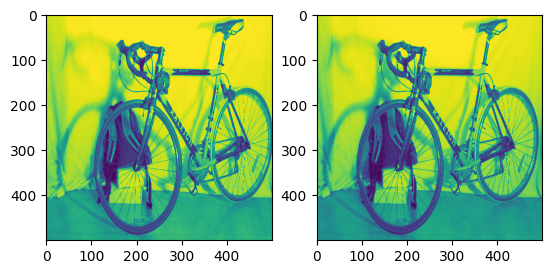

In [2]:
img1 = cv2.imread('images/im0.png',0)
img2 = cv2.imread('images/im1.png',0)
img1 = cv2.resize(img1, (500, 500))
img2 = cv2.resize(img2, (500, 500))
plt.subplot(121),plt.imshow(img1)
plt.subplot(122),plt.imshow(img2)
plt.show()

Definimos las funciones auxiliares que utilizaremos en el método principal:
- `new_image_like()`: Crea un lienzo nuevo para guardar los valores de profundidad.
- `get_feature_descriptor()`: Extrae una ventana de la imagen.
- `score_feature_match()`: Calcula la diferencia entre dos ventanas.

In [3]:
def new_image_like(img):
    """Crea un lienzo nuevo para guardar los valores de profundidad."""
    return np.zeros_like(img, dtype=np.float32) # reciclado de la práctica anterior

def get_feature_descriptor(img, i, j): # reciclado de la práctica anterior
    """Extrae una ventana de la imagen."""
    x1 = max(0, i - 2)
    x2 = min(img.shape[1], i + 3)

    y1 = max(0, j - 2)
    y2 = min(img.shape[0], j + 3)

    mask = img[y1:y2, x1:x2]
    return mask

def score_feature_match(f_ij, f_i2j):
    """Calcula la diferencia entre dos ventanas."""
    return math.dist(f_ij.ravel(), f_i2j.ravel())

Implementamos el algoritmo del PDF usando la formulación de la profundidad de la [página de Middlebury](https://vision.middlebury.edu/stereo/data/scenes2014/). Añadimos un epsilon para evitar divisiones por cero.

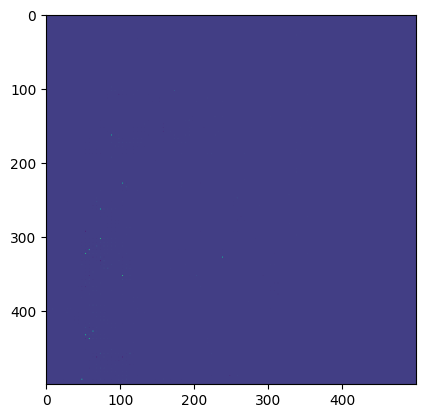

In [4]:
def compute_depth(img1, img2, baseline, f, doffs):
    depth = new_image_like(img1)
    height, width = img1.shape
    _, width2 = img2.shape
    for i in range(3, width-2, 5):
        for j in range(3, height-2, 5):
            f_ij = get_feature_descriptor(img1, i, j)
            best_score = np.inf
            best_i = np.nan
            for i2 in range(3, width2-2):
                f_i2j = get_feature_descriptor(img2, i2, j)
                score = score_feature_match(f_ij, f_i2j)
                if score < best_score:
                    best_score = score
                    best_i = i2
            depth[j, i] = baseline * f / (i - best_i + doffs + EPSILON) # Añadimos un epsilon para evitar divisiones por cero
    return depth

f= 5299.313
width=2988
height=2008
doffs=174.186
baseline=177.288 #in mm
EPSILON = 0.000001
depth_img = compute_depth(img1, img2, baseline, f, doffs)
plt.imshow(depth_img)

La solución anterior solo pinta el píxel central de la ventana. Por tanto, necesitamos pintar todos los píxeles de la ventana con el valor obtenido. Le preguntamos a ChatGPT cómo pintar la ventana completa y nos sugirió que devolviésemos las coordenadas de la ventana para luego aplicar el mismo valor en todos sus píxeles.

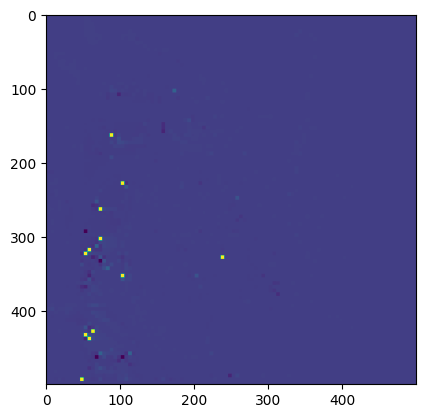

In [ ]:

def get_feature_descriptor(img, i, j):
    """Extrae una ventana de la imagen."""
    x1 = max(0, i - 2)
    x2 = min(img.shape[1], i + 3)

    y1 = max(0, j - 2)
    y2 = min(img.shape[0], j + 3)

    mask = img[y1:y2, x1:x2]
    return mask, x1, x2, y1, y2


def compute_depth(img1, img2, baseline, f, doffs):
    depth = new_image_like(img1)
    height, width = img1.shape
    _, width2 = img2.shape

    for i in range(3, width-2, 5):
        for j in range(3, height-2, 5):
            f_ij, x1, x2, y1, y2 = get_feature_descriptor(img1, i, j)
            best_score = np.inf
            best_i = np.nan

            for i2 in range(3, width2-2):
                f_i2j, _, _, _, _ = get_feature_descriptor(img2, i2, j)
                score = score_feature_match(f_ij, f_i2j)
                if score < best_score:
                    best_score = score
                    best_i = i2
            
            disparity = i - best_i
            depth_val = baseline * f / (disparity + doffs + EPSILON)
            # pintamos toda la ventana
            depth[y1:y2, x1:x2] = depth_val

    return depth

f= 5299.313
width=2988
height=2008
doffs=174.186
baseline=177.288 #in mm
EPSILON = 0.000001
depth_img = compute_depth(img1, img2, baseline, f, doffs)
plt.imshow(depth_img)

Seguimos sin ver la figura con nitidez. Este problema, comentado en clase, se soluciona poniendo un umbral para que los valores de disparidad cuando se compara un punto con el fondo, no afecten a la imagen. Por tanto, establecemos un umbral para que a aquellos valores que pertenezcan al fondo se les asigne el valor máximo de los puntos que no forman parte del fondo.

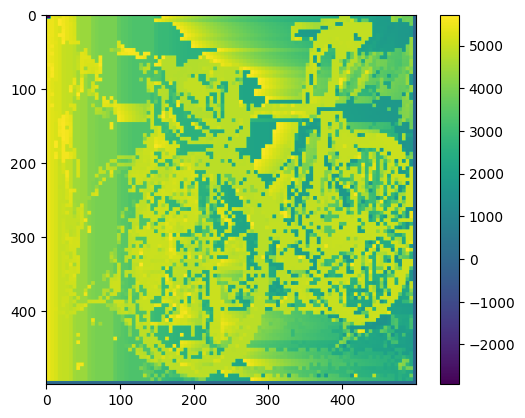

In [14]:
def compute_depth(img1, img2, baseline, f, doffs):
    depth = new_image_like(img1)
    height, width = img1.shape
    _, width2 = img2.shape
    values = []

    for i in range(3, width-2, 5):
        for j in range(3, height-2, 5):
            f_ij, x1, x2, y1, y2 = get_feature_descriptor(img1, i, j)
            best_score = np.inf
            best_i = np.nan

            for i2 in range(3, width2-2):
                f_i2j, _, _, _, _ = get_feature_descriptor(img2, i2, j)
                score = score_feature_match(f_ij, f_i2j)
                if score < best_score:
                    best_score = score
                    best_i = i2
            
            # Umbral comentado en clase
            disparity = i - best_i
            if disparity < -10 and len(values)!=0:
                disparity = max(values)
                values.append(disparity)
            else:
                values.append(disparity)

            depth_val = baseline * f / (disparity + doffs + EPSILON)
            # pintamos toda la ventana
            depth[y1:y2, x1:x2] = depth_val

    return depth


f= 5299.313
width=2988
height=2008
doffs=174.186
baseline=177.288 #in mm
EPSILON = 0.000001
depth_img = compute_depth(img1, img2, baseline, f, doffs)
plt.imshow(depth_img)
plt.colorbar()
plt.show()


El resultado obtenido corresponde a la salida del algoritmo usando una ventana de `5x5` con un escalado previo a `(500, 500)` para acelerar el procesamiento. Se obtiene un resultado poco nítido pero se intuye la forma de la bicicleta.